In [6]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [7]:
model= YOLO("runs/uav_detector-5/weights/best.pt")


In [8]:
import os

test_dir = "dataset/test"
seq = os.listdir(test_dir)[0]  # İlk dizini alıyoruz (örneğin "seq1")
img_dir = os.path.join(test_dir, seq)
img_name = sorted(os.listdir(img_dir))[0]  # İlk görüntüyü alıyoruz  sorted ile sıralıyoruz
img_path = os.path.join(img_dir, img_name)

print(f"Test görüntüsü: {img_path}")


Test görüntüsü: dataset/test/20190925_200805_1_2/000001.jpg


In [9]:
results = model(img_path)



image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_200805_1_2/000001.jpg: 256x320 1 uav, 38.0ms
Speed: 1.1ms preprocess, 38.0ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 320)


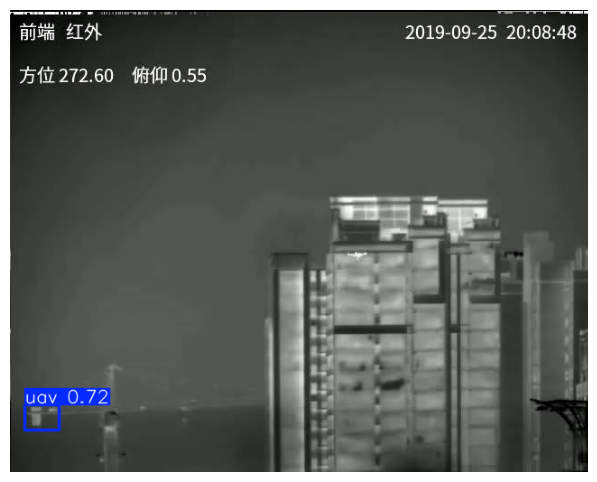

In [10]:
import matplotlib.pyplot as plt

annotated = results[0].plot()  # İlk sonuçtaki anotasyonu alıyoruz
annotated_rgb = annotated[:, :, ::-1]  # BGR'den RGB'ye dönüştürme
plt.figure(figsize=(10, 6))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

In [11]:
boxes = results[0].boxes
print("Kaç tane tespit:", len(boxes))                                  
print("Koordinatlar (x1,y1,x2,y2):", boxes.xyxy)                       
print("Güven skoru:", boxes.conf)                                      
print("Sınıf:", boxes.cls)

Kaç tane tespit: 1
Koordinatlar (x1,y1,x2,y2): tensor([[ 16.0284, 437.0436,  54.0801, 465.4497]])
Güven skoru: tensor([0.7225])
Sınıf: tensor([0.])



0: 256x320 1 uav, 26.2ms
1: 256x320 (no detections), 26.2ms
2: 256x320 1 uav, 26.2ms
3: 256x320 1 uav, 26.2ms
4: 256x320 (no detections), 26.2ms
Speed: 0.4ms preprocess, 26.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 320)


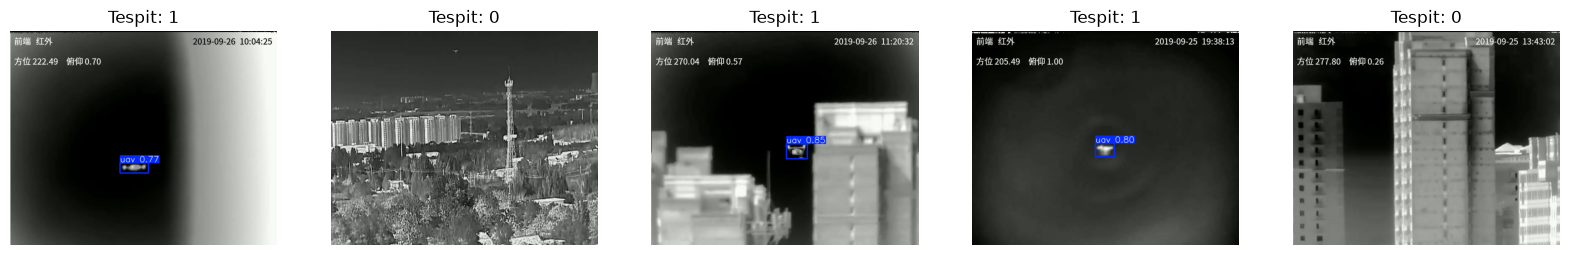

In [12]:
import random                                                          
                                                                         
seq_list = os.listdir(test_dir)      # test dizinindeki tüm sequence'leri alıyoruz       
test_images = []  # test imageları almak için boş bir liste oluşturuyoruz                                                       
                  
for seq in random.sample(seq_list, 5):   # rastgele 5 sequence         
    img_dir = os.path.join(test_dir, seq)
    frames = sorted(os.listdir(img_dir))                               
    frames = [f for f in frames if f.endswith(".jpg")]                 
    if frames:  # frame varsa, ilk frame'i alıyoruz                          
       test_images.append(os.path.join(img_dir, frames[0]))           
                                                                       
results_multi = model(test_images)      # 5 görüntüyü de modele veriyoruz
                                                                         
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 5 görüntü için subplot oluşturuyoruz                      
for i, (r, ax) in enumerate(zip(results_multi, axes)):
    ax.imshow(r.plot()[:, :, ::-1])                                    
    ax.axis("off")                                                     
    ax.set_title(f"Tespit: {len(r.boxes)}") 
plt.show() 

In [1]:
import sys
sys.path.append("/Users/mehmetdegirmenci/Desktop/Microsoft proje")

from src.kalman import kalmanFilter

tracker = kalmanFilter(100, 200)

pred = tracker.predict()
print("Tahmin : " , pred)

updated = tracker.update(105 , 203)
print("Güncelleme sonrası:", updated)

pred2 = tracker.predict()
print("2. Tahmin : " , pred2)


Tahmin :  [100. 200.]
Güncelleme sonrası: [104.97512562 202.98507537]
2. Tahmin :  [107.46256405 204.47753843]


In [ ]:
""" 
Tahmin :  [100. 200.]  ilk başlangıç noktası zaten 0 olacak
Güncelleme sonrası: [104.97512562 202.98507537]  
2. Tahmin :  [107.46256405 204.47753843]

"""

In [3]:
tracker2 = kalmanFilter(100, 200)                                      
                                                                         
# YOLO görüyor
tracker2.predict()                                                         
tracker2.update(105, 203)

tracker2.predict()
tracker2.update(110, 206)                                              

tracker2.predict()
tracker2.update(115, 209)                                              
                                                                         
print("YOLO kayboldu, sadece tahminle devam:")
for i in range(3):                                                     
    pred = tracker2.predict()
    print(f"  Frame {i+1} tahmini:", pred) 

YOLO kayboldu, sadece tahminle devam:
  Frame 1 tahmini: [119.95099391 211.97059635]
  Frame 2 tahmini: [124.92649126 214.95589476]
  Frame 3 tahmini: [129.90198861 217.94119317]
